<a href="https://colab.research.google.com/github/Parul077/ML_Projects/blob/main/xray_image_classification_using_Pre_trained_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

# Check if the mounted directory exists before listing its contents
if os.path.exists('/content/drive/MyDrive'):
  !ls /content/drive/MyDrive
else:
  print("Google Drive is not mounted or the MyDrive directory does not exist.")

 Classroom				        NewProject.zip
'Colab Notebooks'			       'Papa adhaar.pdf'
'high, intermediate.pdf'		       'Passport photo.jpg'
'Id card.pdf'				        Pdf-Updation.zip
'List of available LLMs.gdoc'		        pnuemonia_xray_images.zip
'machine learning (1).pptx'		        Resume_ParulSingh-ML.pdf
'Machine learning for internship_V2.0[1].pdf'   SURGE_IITK.zip
'My adhaar.pdf'				        x-ray_data


In [4]:
!unzip /content/drive/MyDrive/pnuemonia_xray_images.zip

Streaming output truncated to the last 5000 lines.
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-1192-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-1258-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-1183-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-1258-0001-0002.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-1228-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-1202-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-1176-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-1261-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-1234-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-1188-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-1198-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-1254-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-1242-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-1189-0001.jpeg  
  inflating: chest_xray/train

In [5]:
# importing the libraries

import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

In [6]:
# setting the training data directory
DataDir = r"chest_xray/train/"

In [7]:
# initiallizing the category of classification
CATEGORIES = ["NORMAL", "PNEUMONIA"]

In [8]:
!ls chest_xray/test

NORMAL	PNEUMONIA


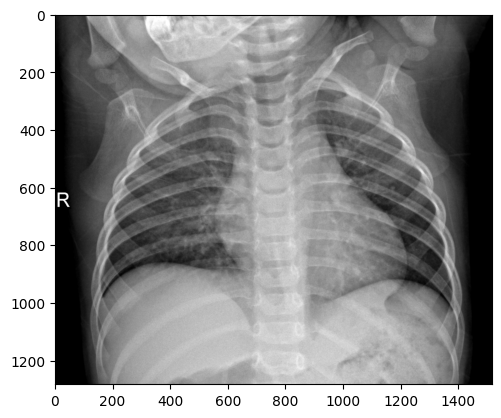

In [9]:
# converting the images into grayscale
for i in CATEGORIES:
    path=os.path.join(DataDir,i)
    for img in os.listdir(path):
        img_array=cv2.imread(os.path.join(path,img),cv2.IMREAD_GRAYSCALE)
        plt.imshow(img_array,cmap='gray')
        plt.show()
        break
    break

In [10]:
# initializing the size of the image so that every image should be in same dimension

img_size = 100

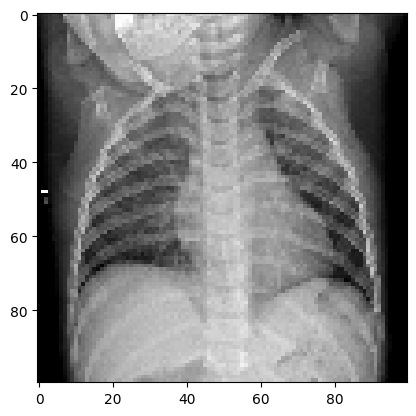

In [11]:
# image after resize and gray scale

new_array=cv2.resize(img_array,(img_size,img_size))
plt.imshow(new_array,cmap='gray')
plt.show()

In [12]:
training_data = []

In [13]:
# defining the function for training data according to the categories converting the images into gray scale with resizing the image 100X100
# converting into numpy arrays
def create_training_data():
  for i in CATEGORIES:

    path = os.path.join(DataDir, i)
    class_num = CATEGORIES.index(i)

    for img in os.listdir(path):
      try:
        img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
        new_array = cv2.resize(img_array, (img_size, img_size))
        training_data.append([new_array, class_num])

      except Exception as e:
        pass

In [14]:
create_training_data()

In [15]:
print(len(training_data))

5226


In [16]:
import random
random.shuffle(training_data)
for sample in training_data[:10]:
  print(sample)

[array([[47, 55, 65, ..., 59, 38, 20],
       [42, 51, 64, ..., 52, 34, 18],
       [42, 52, 64, ..., 48, 27, 17],
       ...,
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0]], dtype=uint8), 0]
[array([[11, 11, 11, ...,  9,  9,  9],
       [ 9,  9,  9, ...,  7,  7,  7],
       [ 8,  8,  7, ...,  5,  5,  5],
       ...,
       [23,  0,  0, ...,  0,  0,  0],
       [23,  0,  1, ...,  0,  0,  0],
       [18,  0,  0, ...,  0,  0,  0]], dtype=uint8), 1]
[array([[105, 114, 117, ...,  69,  75,  69],
       [115, 111, 116, ...,  78,  73,  74],
       [111, 124, 125, ...,  78,  79,  76],
       ...,
       [  0,   0,   1, ...,   0,   0,   0],
       [  0,   0,   2, ...,   0,   0,   0],
       [  0,   0,   6, ...,   0,   0,   0]], dtype=uint8), 1]
[array([[10, 31, 46, ...,  0,  0,  0],
       [ 1, 22, 40, ...,  0,  0,  0],
       [ 0, 13, 34, ...,  0,  0,  0],
       ...,
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ..

In [17]:
X = []
y = []

In [18]:
# splitting the features and labels
for features, label in training_data:
  X.append(features)
  y.append(label)

In [19]:
print(X[0].reshape(-1, img_size, img_size, 1))

[[[[47]
   [55]
   [65]
   ...
   [59]
   [38]
   [20]]

  [[42]
   [51]
   [64]
   ...
   [52]
   [34]
   [18]]

  [[42]
   [52]
   [64]
   ...
   [48]
   [27]
   [17]]

  ...

  [[ 0]
   [ 0]
   [ 0]
   ...
   [ 0]
   [ 0]
   [ 0]]

  [[ 0]
   [ 0]
   [ 0]
   ...
   [ 0]
   [ 0]
   [ 0]]

  [[ 0]
   [ 0]
   [ 0]
   ...
   [ 0]
   [ 0]
   [ 0]]]]


In [20]:
y = np.array(y)

In [21]:
# reshaping the features for making it compatible with the tensorflow
X = np.array(X).reshape(-1, img_size, img_size, 1)

In [22]:
# As we do for training data similarity doing with validation data

validation_data = []
DataDir_val = r"chest_xray/val/"

In [23]:
def create_validating_data():
  for i in CATEGORIES:
    path = os.path.join(DataDir_val, i)
    class_num = CATEGORIES.index(i)
    for img in os.listdir(path):
      try:
        img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
        new_array = cv2.resize(img_array, (img_size, img_size))
        validation_data.append([new_array, class_num])
      except Exception as e:
        pass

In [24]:
create_validating_data()
print(len(validation_data))

16


In [25]:
import random
random.shuffle(validation_data)
for sample in validation_data[:10]:
  print(sample)

[array([[  0,   0,   0, ...,   6,   6,   6],
       [  0,   0,   0, ...,   6,   6,   6],
       [  0,   0,   0, ...,   6,   6,   6],
       ...,
       [  3,   3,   3, ..., 222,  51,   7],
       [  3,   3,   3, ..., 190,  58,  10],
       [  3,   4,   4, ...,  48,  14,   9]], dtype=uint8), 1]
[array([[ 13,  24,  31, ...,   0,   0,   0],
       [ 12,  24,  96, ...,   0,   0,   0],
       [ 11, 254, 163, ...,   0,   0,   0],
       ...,
       [  0,  19,  28, ...,   0,   0,   0],
       [  0,  20,  27, ...,   0,   0,   0],
       [  0,  18,  28, ...,   0,   0,   0]], dtype=uint8), 1]
[array([[64, 63, 64, ..., 97, 93, 93],
       [51, 52, 50, ..., 90, 92, 90],
       [39, 41, 44, ..., 96, 86, 86],
       ...,
       [16, 51, 78, ...,  2,  2,  6],
       [28, 56, 80, ...,  2,  1,  8],
       [35, 61, 87, ...,  2, 10,  7]], dtype=uint8), 1]
[array([[17, 19, 26, ..., 27, 15, 17],
       [18, 23, 33, ..., 53, 43, 22],
       [19, 27, 32, ..., 51, 35, 28],
       ...,
       [ 6,  4,  5, ...,

In [26]:
X_val = []
y_val = []

In [27]:
for features, label in validation_data:
  X_val.append(features)
  y_val.append(label)

In [28]:
y_val = np.array(y_val)
X_val = np.array(X_val).reshape(-1, img_size, img_size, 1)


In [29]:
# importing the libraries for training the model and adding the neural network layers

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D
import pickle

In [30]:
# Pixels value ranges from 0 to 255, 0 means black, 255 means white...
# In order to scale it down to a scale of 0 to 1, we are performing this step

X = X/255.0
x_val = X_val/255.0

In [31]:
X.shape

(5226, 100, 100, 1)

In [32]:
x_val.shape

(16, 100, 100, 1)

In [33]:
# initializing the nueral network layer for training the model

model = Sequential()

model.add(Conv2D(64, (3,3), input_shape = X.shape[1:]))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(.2))

model.add(Conv2D(128, (3,3)))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(.2))

model.add(Conv2D(256, (3,3)))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(.2))

model.add(Flatten())
model.add(Dense(64))

model.add(Dropout(.5))
model.add(Dense(1))
model.add(Activation("sigmoid"))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:
# summary of the model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 98, 98, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 49, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 47, 47, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 21, 21, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,638,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,008,193 (7.66 MB)

 Trainable params: 2,008,193 (7.66 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [36]:
# fitting the model with 10 epochs and using the validation data we have created
model.fit(X, y, batch_size=32, epochs=10, validation_data=(x_val, y_val))

Epoch 1/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 269s 2s/step - accuracy: 0.7593 - loss: 0.6054 - val_accuracy: 0.6250 - val_loss: 0.7156
Epoch 2/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 286s 2s/step - accuracy: 0.9460 - loss: 0.1445 - val_accuracy: 0.6250 - val_loss: 0.5638
Epoch 3/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 312s 2s/step - accuracy: 0.9509 - loss: 0.1187 - val_accuracy: 0.8125 - val_loss: 0.4943
Epoch 4/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 276s 2s/step - accuracy: 0.9622 - loss: 0.0933 - val_accuracy: 0.9375 - val_loss: 0.1006
Epoch 5/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 260s 2s/step - accuracy: 0.9668 - loss: 0.0927 - val_accuracy: 1.0000 - val_loss: 0.0668
Epoch 6/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 265s 2s/step - accuracy: 0.9664 - loss: 0.0911 - val_accuracy: 0.8125 - val_loss: 0.2297
Epoch 7/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 319s 2s/step - accuracy: 0.9689 - loss: 0.0797 - val_accuracy: 1.0000 - val_loss: 0.1168
Epoch 8/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 267s 2s/step - accuracy: 0.9782 - loss: 0.0623 - val_accu

In [37]:
# saving the model
model.save('pneumonia_detection_model.h5')

In [38]:
# importing the libraries for testing the model

import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.models import load_model

In [39]:
CATEGORIES = ["NORMAL", "PNEUMONIA"]

In [40]:
# function for preparing the image for predicting the class

def prepare(image):
  img_size = 100
  #img_array=cv2.imread(image,cv2.IMREAD_GRAYSCALE)
  img=tf.keras.preprocessing.image.load_img(image, color_mode='grayscale', target_size=(img_size,img_size))
  new_array=tf.keras.preprocessing.image.img_to_array(img)

  return new_array.reshape(-1,img_size,img_size,1)


In [41]:
model = tf.keras.models.load_model('pneumonia_detection_model.h5')

In [42]:
image = r"/content/chest_xray/train/PNEUMONIA/person647_virus_1228.jpeg"

In [43]:
prediction = model.predict([prepare(image)/255.0])
print(prediction)
print(round(prediction[0][0]))
print(CATEGORIES[round(prediction[0][0])])

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=('Tensor(shape=(1, 100, 100, 1))',)
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
[[0.91044664]]
1
PNEUMONIA


In [44]:
image2 = r'/content/chest_xray/train/NORMAL/NORMAL2-IM-0702-0001.jpeg'

In [45]:
prediction=model.predict([prepare(image2)/255.0])
print(prediction)
print(round(prediction[0][0]))
print(CATEGORIES[int(round(prediction[0][0]))])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
[[1.040599e-06]]
0
NORMAL


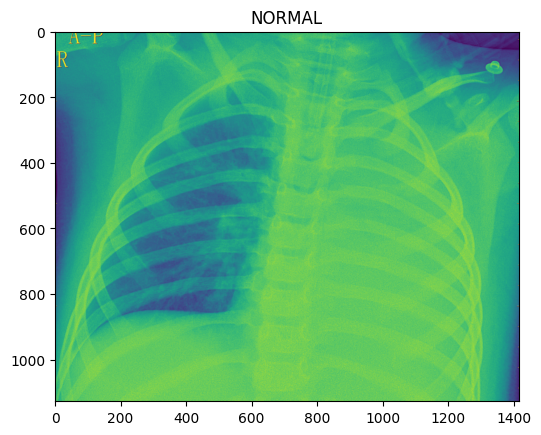

In [46]:
img=mpimg.imread(image)
imgplot=plt.imshow(img)
plt.title(CATEGORIES[int(prediction[0][0])])
plt.show()

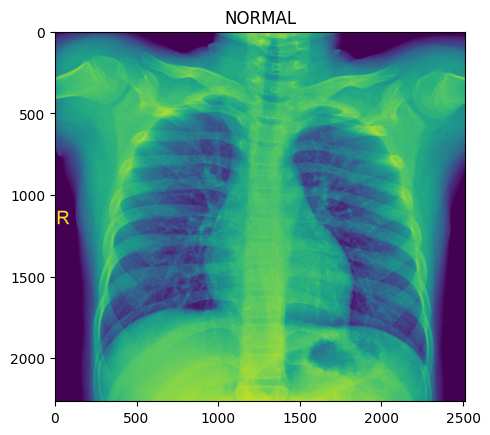

In [47]:
img=mpimg.imread(image2)
imgplot=plt.imshow(img)
plt.title(CATEGORIES[int(prediction[0][0])])
plt.show()

In [48]:
# importing necessary libraries
import os
import cv2
import numpy as np
import tensorflow as tf
from keras.models import load_model

# set the path for the test data
test_dir = r'/content/chest_xray/test'

# define categories
CATEGORIES = ['NORMAL', 'PNEUMONIA']

# set image size
img_size = 100

# load the trained model
model = load_model('pneumonia_detection_model.h5')

# initialize lists for storing test data
X_test = []
y_test = []

# loop through the test data directory and extract the images and their labels
for category in CATEGORIES:
    path = os.path.join(test_dir, category)
    class_num = CATEGORIES.index(category)
    for img in os.listdir(path):
        try:
            img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
            new_array = cv2.resize(img_array, (img_size, img_size))
            X_test.append(new_array)
            y_test.append(class_num)
        except Exception as e:
            pass

# convert test data to numpy arrays
X_test = np.array(X_test).reshape(-1, img_size, img_size, 1)
y_test = np.array(y_test)

# normalize test data
X_test = X_test / 255.0

# calculate test accuracy
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)

# print test accuracy
print('Test accuracy:', test_acc)

20/20 - 7s - 374ms/step - accuracy: 0.7756 - loss: 1.3603
Test accuracy: 0.7756410241127014


## Pre-Trained Models

In [49]:
# import necessary libraries
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [50]:
# define image size
img_size = 100

# load the pre-trained model (VGG16)
base_model = VGG16(input_shape=(img_size,img_size,3), include_top=False, weights='imagenet')

# freeze the layers of the pre-trained model
for layer in base_model.layers:
    layer.trainable = False

# add custom layers for classification
x = Flatten()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
predictions = Dense(1, activation='sigmoid')(x)

# create a new model
model = Model(inputs=base_model.input, outputs=predictions)

# compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# define the image generators for training and validation data
train_datagen = ImageDataGenerator(rescale=1./255, shear_range=0.2, zoom_range=0.2, horizontal_flip=True)
val_datagen = ImageDataGenerator(rescale=1./255)

# specify the training and validation data directories
train_dir = r'/content/chest_xray/train'
val_dir = r'/content/chest_xray/val'

# create the image generators for training and validation data
train_generator = train_datagen.flow_from_directory(train_dir, target_size=(img_size, img_size), batch_size=32, class_mode='binary')
val_generator = val_datagen.flow_from_directory(val_dir, target_size=(img_size, img_size), batch_size=32, class_mode='binary')

# train the model
model.fit(train_generator, epochs=10, validation_data=val_generator)

# evaluate the model on test data
test_dir = r'/content/chest_xray/test'
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(test_dir, target_size=(img_size, img_size), batch_size=32, class_mode='binary', shuffle=False)
test_loss, test_acc = model.evaluate(test_generator)
print('Test accuracy:', test_acc)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Found 5226 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 616s 4s/step - accuracy: 0.8567 - loss: 0.3159 - val_accuracy: 0.8125 - val_loss: 0.3567
Epoch 2/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 617s 4s/step - accuracy: 0.9397 - loss: 0.1468 - val_accuracy: 0.9375 - val_loss: 0.2114
Epoch 3/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 616s 4s/step - accuracy: 0.9311 - loss: 0.1704 - val_accuracy: 0.8750 - val_loss: 0.1770
Epoch 4/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 615s 4s/step - accuracy: 0.9554 - loss: 0.1238 - val_accuracy: 0.7500 - val_loss: 0.3536
Epoch 5/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 608s 4s/step - accuracy: 0.9512 - loss: 0.1339 - val_accuracy: 0.8750 - val_loss: 0.2620
Epoch 6/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 608s 4s/step - accuracy: 0.9587 - loss: 0.1275 - val_accuracy: 0.8125 - val_loss: 0.2304
Epoch 7/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 610s 4s/step - accuracy: 0.9534 - loss: 0.1243 - val_accuracy: 0.8750 - val_loss: 0.3080
Epoch 8/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 605s 4s/step - accuracy: 0.9526 - loss: 0.1253 - val_accu

In [53]:
# saving the pre-trained model
model.save('pneumonia_detection_model_using_pre-trained_model.h5')

In [54]:
import os

if os.path.exists('pneumonia_detection_model_using_pre-trained_model.h5'):
  print('File pneumonia_detection_model_using_pre-trained_model.h5 found.')
else:
  print('File pneumonia_detection_model_using_pre-trained_model.h5 not found. Please ensure cell m69rHxD8C5JL was executed.')


File pneumonia_detection_model_using_pre-trained_model.h5 found.


Since the model file `pneumonia_detection_model_using_pre-trained_model.h5` was not found, please make sure to run the cell `m69rHxD8C5JL` which saves the pre-trained model. After successfully running that cell, you can then try to load the model in cell `jGEYgq7YLCOF` again.

In [55]:
model.summary()

Model: "functional_51"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 100, 100, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 100, 100, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 50, 50, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 25, 25, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 25, 25, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 25, 25, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 12, 12, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,378,053 (70.11 MB)

 Trainable params: 1,221,121 (4.66 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 2,442,244 (9.32 MB)

In [56]:
# Evaluate the model on test data
test_dir = r'/content/chest_xray/test'
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(test_dir, target_size=(img_size, img_size), batch_size=32, class_mode='binary', shuffle=False)
test_loss, test_acc = model.evaluate(test_generator)
print('Test accuracy:', test_acc)



Found 624 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


20/20 ━━━━━━━━━━━━━━━━━━━━ 71s 4s/step - accuracy: 0.8920 - loss: 0.2735
Test accuracy: 0.9102563858032227
